In [4]:
'''
# M3 — Occupancy Intelligence Analysis

This notebook develops the data analysis and forecasting foundation for the Occupancy System of the Smart Facility Operations and Optimization platform.

### Objectives
- Understand occupancy and environmental sensor data
- Analyze occupancy patterns
- Identify relationships between occupancy and sensor readings
- Generate occupancy intelligence and KPIs
- Build an occupancy forecasting model
- Evaluate forecasting performance
- Prepare outputs for the Occupancy Agent

'''

'\n# M3 — Occupancy Intelligence Analysis\n\nThis notebook develops the data analysis and forecasting foundation for the Occupancy System of the Smart Facility Operations and Optimization platform.\n\n### Objectives\n- Understand occupancy and environmental sensor data\n- Analyze occupancy patterns\n- Identify relationships between occupancy and sensor readings\n- Generate occupancy intelligence and KPIs\n- Build an occupancy forecasting model\n- Evaluate forecasting performance\n- Prepare outputs for the Occupancy Agent\n\n'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
DATA_PATH = Path("../data/raw/Occupancy_Estimation.csv")

print("Dataset path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

Dataset path: ..\data\raw\Occupancy_Estimation.csv
File exists: True


In [7]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (10129, 19)


In [8]:
df.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [9]:
df.tail()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
10124,2018/01/11,08:58:07,25.06,25.13,24.69,25.31,6,7,33,22,0.09,0.04,0.06,0.08,345,0.0,0,0,0
10125,2018/01/11,08:58:37,25.06,25.06,24.69,25.25,6,7,34,22,0.07,0.05,0.05,0.08,345,0.0,0,0,0
10126,2018/01/11,08:59:08,25.13,25.06,24.69,25.25,6,7,34,22,0.11,0.05,0.06,0.08,345,0.0,0,0,0
10127,2018/01/11,08:59:39,25.13,25.06,24.69,25.25,6,7,34,22,0.08,0.08,0.10,0.08,345,0.0,0,0,0
10128,2018/01/11,09:00:09,25.13,25.06,24.69,25.25,6,7,34,22,0.08,0.05,0.06,0.08,345,0.0,0,0,0


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10129
Number of columns: 19


In [11]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the dataset:

1. Date
2. Time
3. S1_Temp
4. S2_Temp
5. S3_Temp
6. S4_Temp
7. S1_Light
8. S2_Light
9. S3_Light
10. S4_Light
11. S1_Sound
12. S2_Sound
13. S3_Sound
14. S4_Sound
15. S5_CO2
16. S5_CO2_Slope
17. S6_PIR
18. S7_PIR
19. Room_Occupancy_Count


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope       

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Temp,10129.0,25.454012,0.351351,24.940000,25.190000,25.38,25.63,26.380000
S2_Temp,10129.0,25.546059,0.586325,24.750000,25.190000,25.38,25.63,29.000000
S3_Temp,10129.0,25.056621,0.427283,24.440000,24.690000,24.94,25.38,26.190000
S4_Temp,10129.0,25.754125,0.356434,24.940000,25.440000,25.75,26.00,26.560000
S1_Light,10129.0,25.445059,51.011264,0.000000,0.000000,0.00,12.00,165.000000
S2_Light,10129.0,26.016290,67.304170,0.000000,0.000000,0.00,14.00,258.000000
S3_Light,10129.0,34.248494,58.400744,0.000000,0.000000,0.00,50.00,280.000000
S4_Light,10129.0,13.220259,19.602219,0.000000,0.000000,0.00,22.00,74.000000
S1_Sound,10129.0,0.168178,0.316709,0.060000,0.070000,0.08,0.08,3.880000
S2_Sound,10129.0,0.120066,0.266503,0.040000,0.050000,0.05,0.06,3.440000


In [14]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (missing_values / len(df)) * 100
})

missing_summary.sort_values(
    by="Missing_Count",
    ascending=False
)

,Missing_Count,Missing_Percentage
Date,0,0.0
Time,0,0.0
S1_Temp,0,0.0
S2_Temp,0,0.0
S3_Temp,0,0.0
S4_Temp,0,0.0
S1_Light,0,0.0
S2_Light,0,0.0
S3_Light,0,0.0
S4_Light,0,0.0


In [15]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing values found.")
else:
    print("Missing values are present.")

Total missing values: 0
No missing values found.


In [16]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 0.00%


In [18]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique() for col in df.columns]
})

unique_summary

,Column,Unique_Values
0,Date,7
1,Time,10129
2,S1_Temp,24
3,S2_Temp,69
4,S3_Temp,29
5,S4_Temp,27
6,S1_Light,68
7,S2_Light,82
8,S3_Light,177
9,S4_Light,75


In [19]:
occupancy_counts = df["Room_Occupancy_Count"].value_counts().sort_index()

occupancy_counts

Room_Occupancy_Count
0    8228
1     459
2     748
3     694
Name: count, dtype: int64

In [20]:
occupancy_percentage = (
    df["Room_Occupancy_Count"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

occupancy_percentage

Room_Occupancy_Count
0    81.232106
1     4.531543
2     7.384737
3     6.851614
Name: proportion, dtype: float64

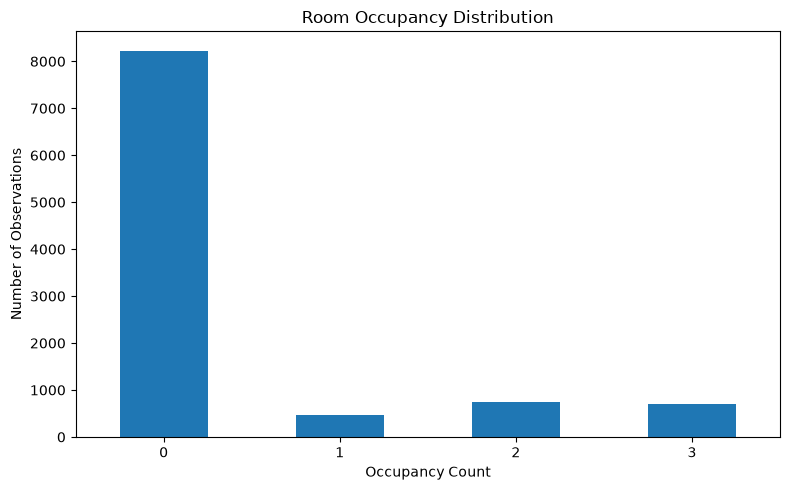

In [21]:
plt.figure(figsize=(8, 5))

occupancy_counts.plot(kind="bar")

plt.title("Room Occupancy Distribution")
plt.xlabel("Occupancy Count")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [22]:
df["Timestamp"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)

print(df[["Date", "Time", "Timestamp"]].head())

         Date      Time           Timestamp
0  2017/12/22  10:49:41 2017-12-22 10:49:41
1  2017/12/22  10:50:12 2017-12-22 10:50:12
2  2017/12/22  10:50:42 2017-12-22 10:50:42
3  2017/12/22  10:51:13 2017-12-22 10:51:13
4  2017/12/22  10:51:44 2017-12-22 10:51:44


In [23]:
print("Invalid timestamps:", df["Timestamp"].isna().sum())

print(
    "Start timestamp:",
    df["Timestamp"].min()
)

print(
    "End timestamp:",
    df["Timestamp"].max()
)

Invalid timestamps: 0
Start timestamp: 2017-12-22 10:49:41
End timestamp: 2018-01-11 09:00:09


In [24]:
is_sorted = df["Timestamp"].is_monotonic_increasing

print("Timestamp sorted:", is_sorted)

Timestamp sorted: True


In [25]:
df = df.sort_values("Timestamp").reset_index(drop=True)

print("Dataset sorted chronologically.")

Dataset sorted chronologically.


In [26]:
time_difference = df["Timestamp"].diff().dropna()

print("Most common time interval:")
print(time_difference.value_counts().head())

Most common time interval:
Timestamp
0 days 00:00:31    6373
0 days 00:00:30    3614
0 days 00:01:01     131
0 days 00:02:34       2
0 days 00:01:02       2
Name: count, dtype: int64


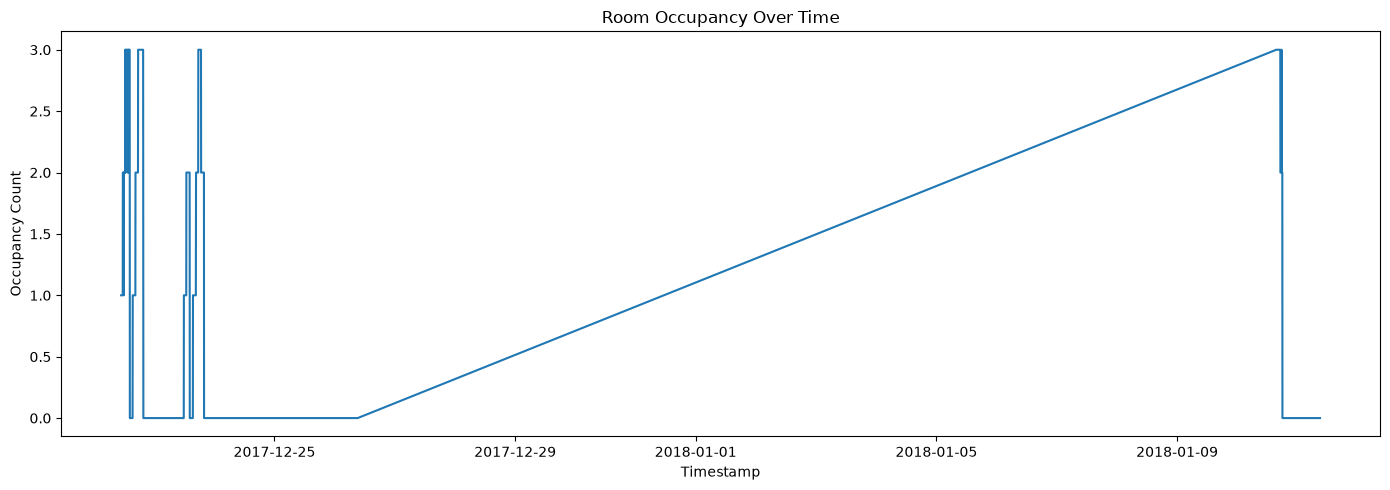

In [27]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Timestamp"],
    df["Room_Occupancy_Count"]
)

plt.title("Room Occupancy Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Occupancy Count")

plt.tight_layout()
plt.show()

In [28]:
occupancy_stats = df["Room_Occupancy_Count"].describe()

occupancy_stats

count    10129.000000
mean         0.398559
std          0.893633
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Room_Occupancy_Count, dtype: float64

In [29]:
occupancy_kpis = {
    "Average Occupancy": df["Room_Occupancy_Count"].mean(),
    "Maximum Occupancy": df["Room_Occupancy_Count"].max(),
    "Minimum Occupancy": df["Room_Occupancy_Count"].min(),
    "Median Occupancy": df["Room_Occupancy_Count"].median()
}

occupancy_kpis

{'Average Occupancy': np.float64(0.3985585941356501),
 'Maximum Occupancy': np.int64(3),
 'Minimum Occupancy': np.int64(0),
 'Median Occupancy': np.float64(0.0)}

In [30]:
df["Hour"] = df["Timestamp"].dt.hour
df["Minute"] = df["Timestamp"].dt.minute
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["DayName"] = df["Timestamp"].dt.day_name()

df[[
    "Timestamp",
    "Hour",
    "Minute",
    "DayOfWeek",
    "DayName",
    "Room_Occupancy_Count"
]].head()

,Timestamp,Hour,Minute,DayOfWeek,DayName,Room_Occupancy_Count
0,2017-12-22 10:49:41,10,49,4,Friday,1
1,2017-12-22 10:50:12,10,50,4,Friday,1
2,2017-12-22 10:50:42,10,50,4,Friday,1
3,2017-12-22 10:51:13,10,51,4,Friday,1
4,2017-12-22 10:51:44,10,51,4,Friday,1


In [31]:
hourly_occupancy = (
    df.groupby("Hour")["Room_Occupancy_Count"]
    .mean()
)

hourly_occupancy

Hour
0     0.000000
1     0.000000
2     0.000000
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.082353
11    0.552326
12    1.028571
13    1.546547
14    0.363112
15    0.808717
16    1.454348
17    1.735484
18    1.412527
19    0.880266
20    0.000000
21    0.000000
22    0.000000
23    0.000000
Name: Room_Occupancy_Count, dtype: float64

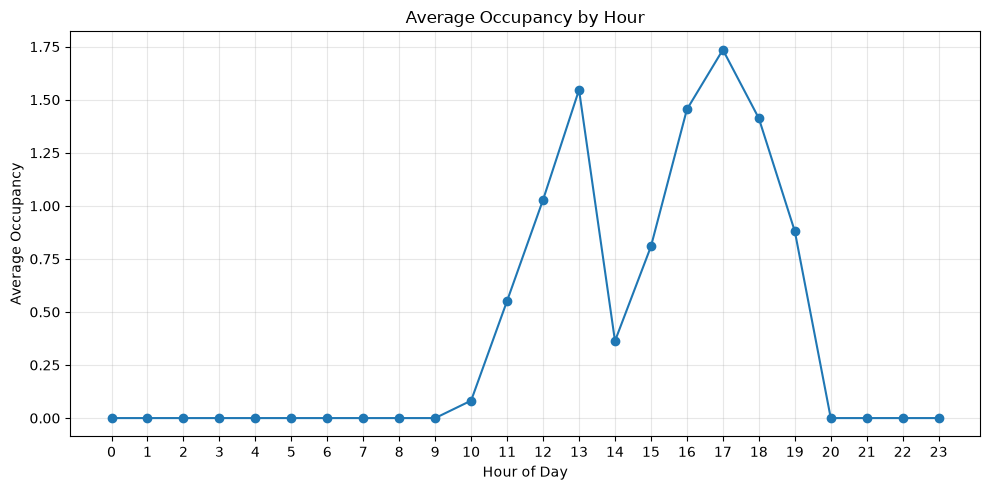

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_occupancy.index,
    hourly_occupancy.values,
    marker="o"
)

plt.title("Average Occupancy by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.xticks(range(24))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
daily_occupancy = (
    df.groupby("DayName")["Room_Occupancy_Count"]
    .mean()
)

daily_occupancy

DayName
Friday       1.236662
Monday       0.000000
Saturday     0.518172
Sunday       0.000000
Thursday     0.000000
Tuesday      0.000000
Wednesday    0.791374
Name: Room_Occupancy_Count, dtype: float64

In [34]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_occupancy = daily_occupancy.reindex(day_order)

daily_occupancy

DayName
Monday       0.000000
Tuesday      0.000000
Wednesday    0.791374
Thursday     0.000000
Friday       1.236662
Saturday     0.518172
Sunday       0.000000
Name: Room_Occupancy_Count, dtype: float64

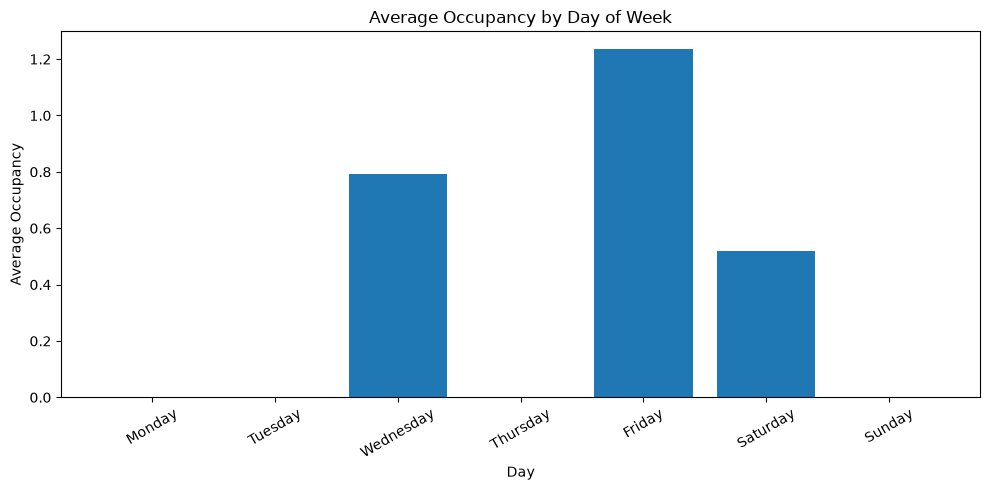

In [35]:
plt.figure(figsize=(10, 5))

plt.bar(
    daily_occupancy.index,
    daily_occupancy.values
)

plt.title("Average Occupancy by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Occupancy")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [36]:
sensor_columns = [
    col for col in df.columns
    if col.startswith(("S1_", "S2_", "S3_", "S4_", "S5_", "S6_", "S7_"))
]

print("Number of sensor columns:", len(sensor_columns))
print("\nSensor columns:")

for col in sensor_columns:
    print("-", col)

Number of sensor columns: 16

Sensor columns:
- S1_Temp
- S2_Temp
- S3_Temp
- S4_Temp
- S1_Light
- S2_Light
- S3_Light
- S4_Light
- S1_Sound
- S2_Sound
- S3_Sound
- S4_Sound
- S5_CO2
- S5_CO2_Slope
- S6_PIR
- S7_PIR


In [37]:
sensor_summary = df[sensor_columns].describe().T

sensor_summary

,count,mean,std,min,25%,50%,75%,max
S1_Temp,10129.0,25.454012,0.351351,24.940000,25.190000,25.38,25.63,26.380000
S2_Temp,10129.0,25.546059,0.586325,24.750000,25.190000,25.38,25.63,29.000000
S3_Temp,10129.0,25.056621,0.427283,24.440000,24.690000,24.94,25.38,26.190000
S4_Temp,10129.0,25.754125,0.356434,24.940000,25.440000,25.75,26.00,26.560000
S1_Light,10129.0,25.445059,51.011264,0.000000,0.000000,0.00,12.00,165.000000
S2_Light,10129.0,26.016290,67.304170,0.000000,0.000000,0.00,14.00,258.000000
S3_Light,10129.0,34.248494,58.400744,0.000000,0.000000,0.00,50.00,280.000000
S4_Light,10129.0,13.220259,19.602219,0.000000,0.000000,0.00,22.00,74.000000
S1_Sound,10129.0,0.168178,0.316709,0.060000,0.070000,0.08,0.08,3.880000
S2_Sound,10129.0,0.120066,0.266503,0.040000,0.050000,0.05,0.06,3.440000


In [38]:
temperature_columns = [
    col for col in df.columns
    if "_Temp" in col
]

light_columns = [
    col for col in df.columns
    if "_Light" in col
]

sound_columns = [
    col for col in df.columns
    if "_Sound" in col
]

co2_columns = [
    col for col in df.columns
    if "CO2" in col
]

pir_columns = [
    col for col in df.columns
    if "_PIR" in col
]

print("Temperature sensors:", temperature_columns)
print("Light sensors:", light_columns)
print("Sound sensors:", sound_columns)
print("CO2 sensors:", co2_columns)
print("PIR sensors:", pir_columns)


Temperature sensors: ['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp']
Light sensors: ['S1_Light', 'S2_Light', 'S3_Light', 'S4_Light']
Sound sensors: ['S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound']
CO2 sensors: ['S5_CO2', 'S5_CO2_Slope']
PIR sensors: ['S6_PIR', 'S7_PIR']


In [39]:
df[temperature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Temp,10129.0,25.454012,0.351351,24.94,25.19,25.38,25.63,26.38
S2_Temp,10129.0,25.546059,0.586325,24.75,25.19,25.38,25.63,29.00
S3_Temp,10129.0,25.056621,0.427283,24.44,24.69,24.94,25.38,26.19
S4_Temp,10129.0,25.754125,0.356434,24.94,25.44,25.75,26.00,26.56


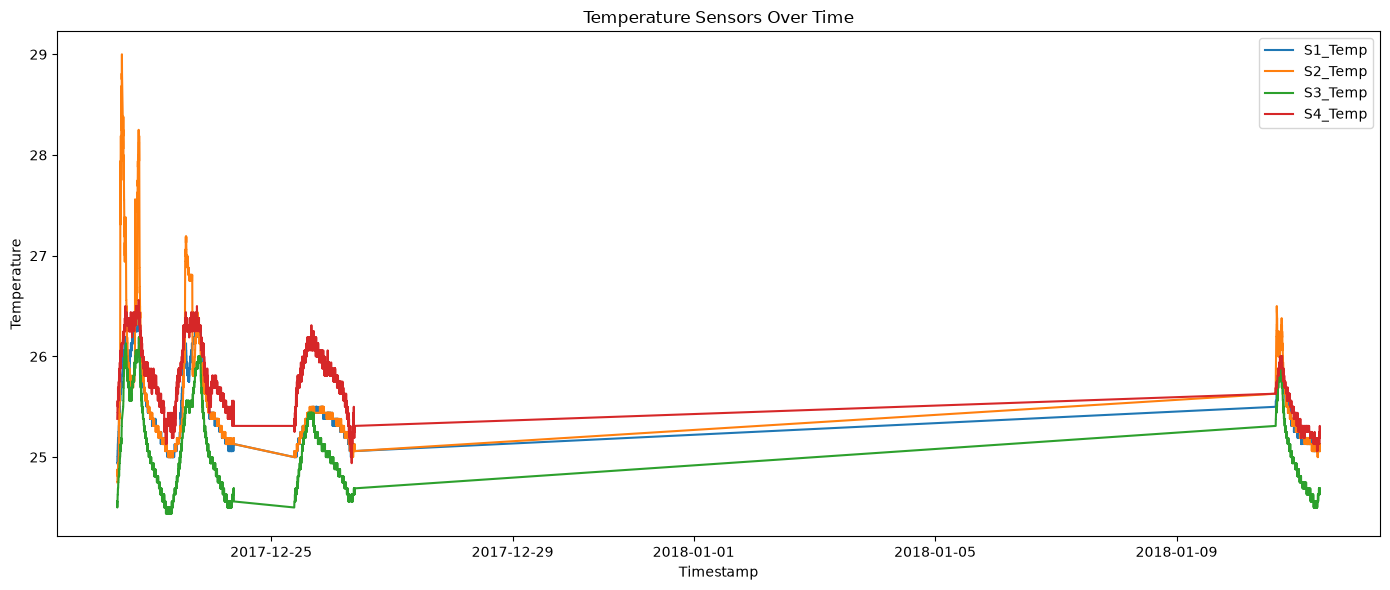

In [40]:
plt.figure(figsize=(14, 6))

for col in temperature_columns:
    plt.plot(
        df["Timestamp"],
        df[col],
        label=col
    )

plt.title("Temperature Sensors Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Temperature")
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
df[light_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Light,10129.0,25.445059,51.011264,0.0,0.0,0.0,12.0,165.0
S2_Light,10129.0,26.016290,67.304170,0.0,0.0,0.0,14.0,258.0
S3_Light,10129.0,34.248494,58.400744,0.0,0.0,0.0,50.0,280.0
S4_Light,10129.0,13.220259,19.602219,0.0,0.0,0.0,22.0,74.0


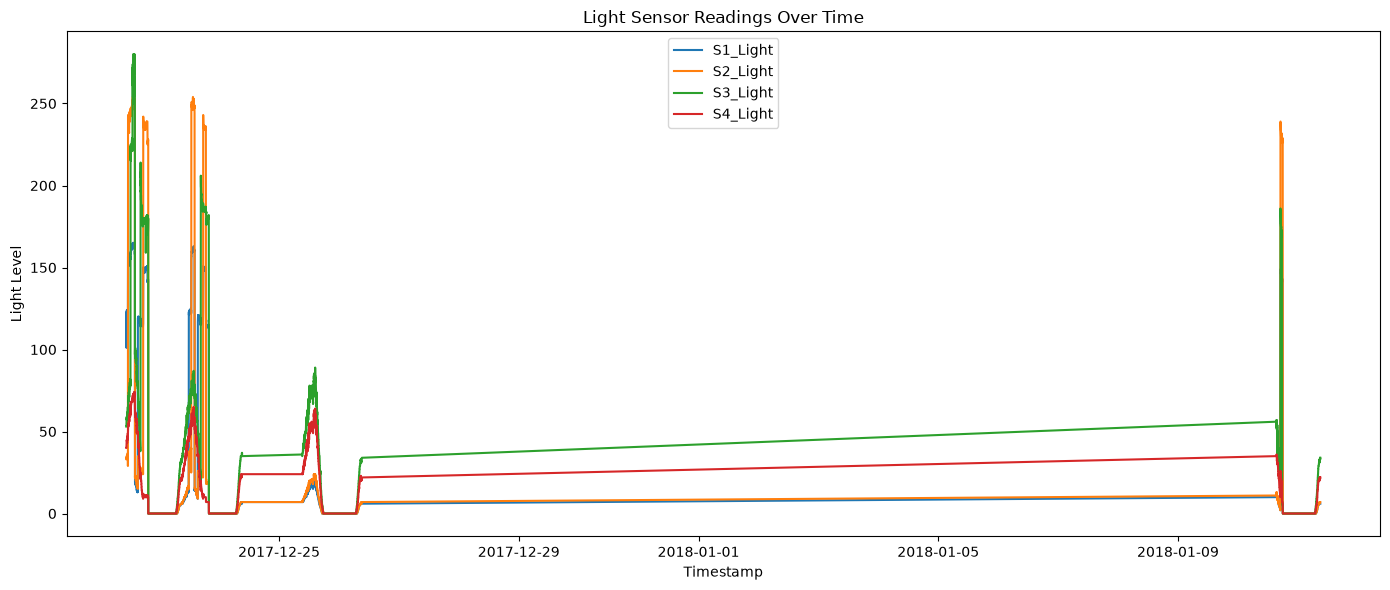

In [42]:
plt.figure(figsize=(14, 6))

for col in light_columns:
    plt.plot(
        df["Timestamp"],
        df[col],
        label=col
    )

plt.title("Light Sensor Readings Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Light Level")
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
df[sound_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
S1_Sound,10129.0,0.168178,0.316709,0.06,0.07,0.08,0.08,3.88
S2_Sound,10129.0,0.120066,0.266503,0.04,0.05,0.05,0.06,3.44
S3_Sound,10129.0,0.158119,0.413637,0.04,0.06,0.06,0.07,3.67
S4_Sound,10129.0,0.103840,0.120683,0.05,0.06,0.08,0.10,3.40


In [44]:
df[co2_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
S5_CO2,10129.0,460.860401,199.96494,345.000000,355.000000,360.0,465.0,1270.000000
S5_CO2_Slope,10129.0,-0.004830,1.16499,-6.296154,-0.046154,0.0,0.0,8.980769


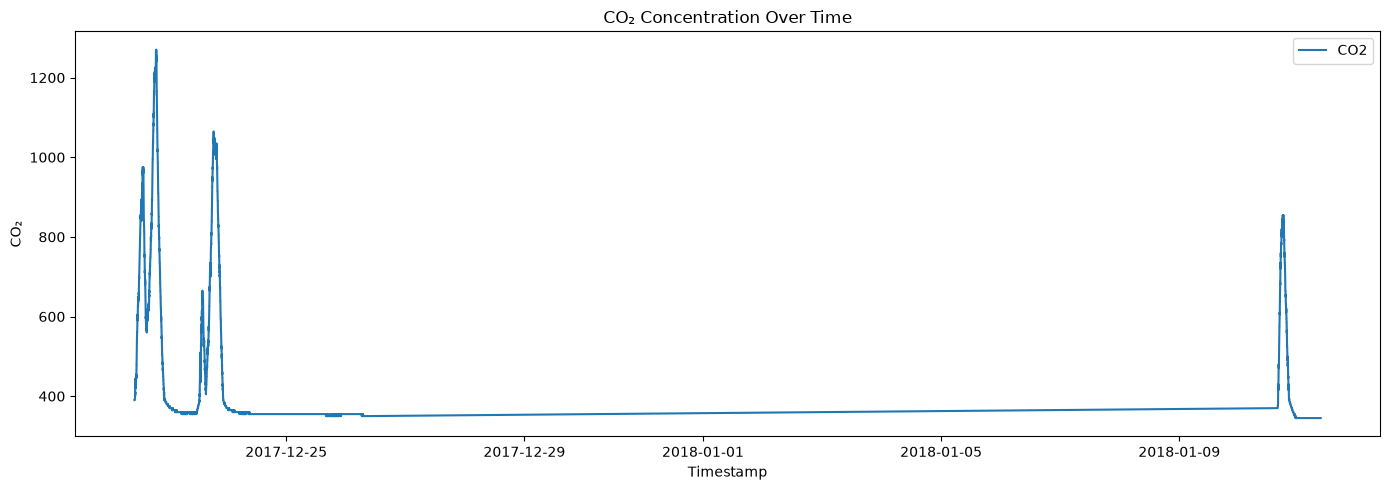

In [45]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["Timestamp"],
    df["S5_CO2"],
    label="CO2"
)

plt.title("CO₂ Concentration Over Time")
plt.xlabel("Timestamp")
plt.ylabel("CO₂")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
df[pir_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
S6_PIR,10129.0,0.090137,0.286392,0.0,0.0,0.0,0.0,1.0
S7_PIR,10129.0,0.079574,0.270645,0.0,0.0,0.0,0.0,1.0


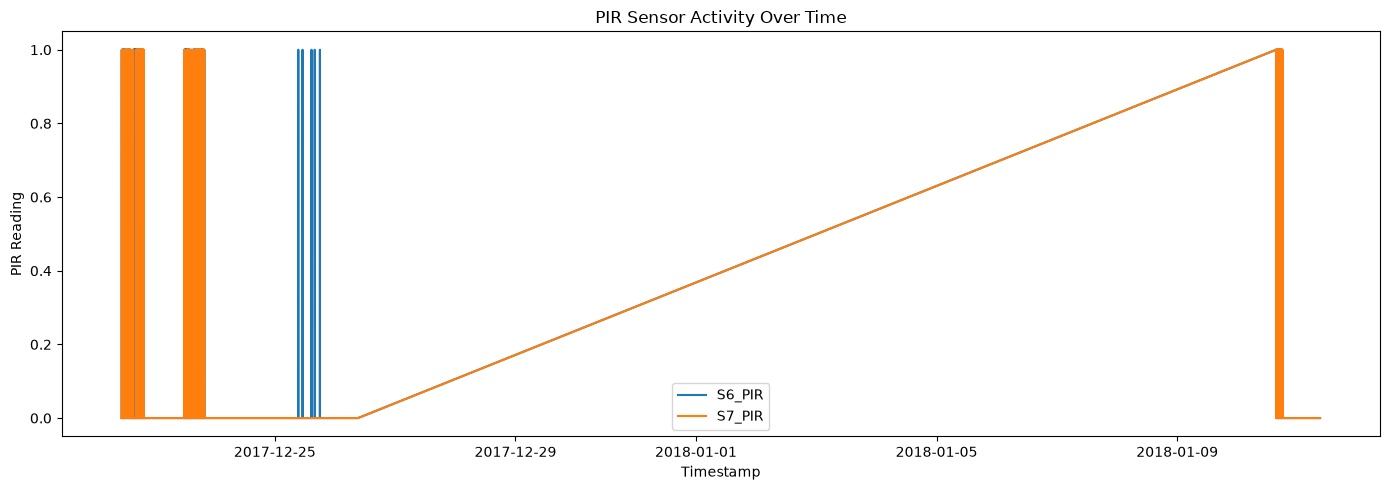

In [47]:
plt.figure(figsize=(14, 5))

for col in pir_columns:
    plt.plot(
        df["Timestamp"],
        df[col],
        label=col
    )

plt.title("PIR Sensor Activity Over Time")
plt.xlabel("Timestamp")
plt.ylabel("PIR Reading")
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
occupancy_correlation = (
    df[sensor_columns + ["Room_Occupancy_Count"]]
    .corr()["Room_Occupancy_Count"]
    .sort_values(ascending=False)
)

occupancy_correlation

Room_Occupancy_Count    1.000000
S1_Light                0.849058
S3_Light                0.793081
S2_Light                0.788764
S1_Temp                 0.700868
S7_PIR                  0.695138
S2_Temp                 0.671263
S5_CO2                  0.660144
S3_Temp                 0.652047
S6_PIR                  0.633133
S5_CO2_Slope            0.601105
S1_Sound                0.573748
S2_Sound                0.557853
S3_Sound                0.531685
S4_Temp                 0.526509
S4_Sound                0.460287
S4_Light                0.355715
Name: Room_Occupancy_Count, dtype: float64

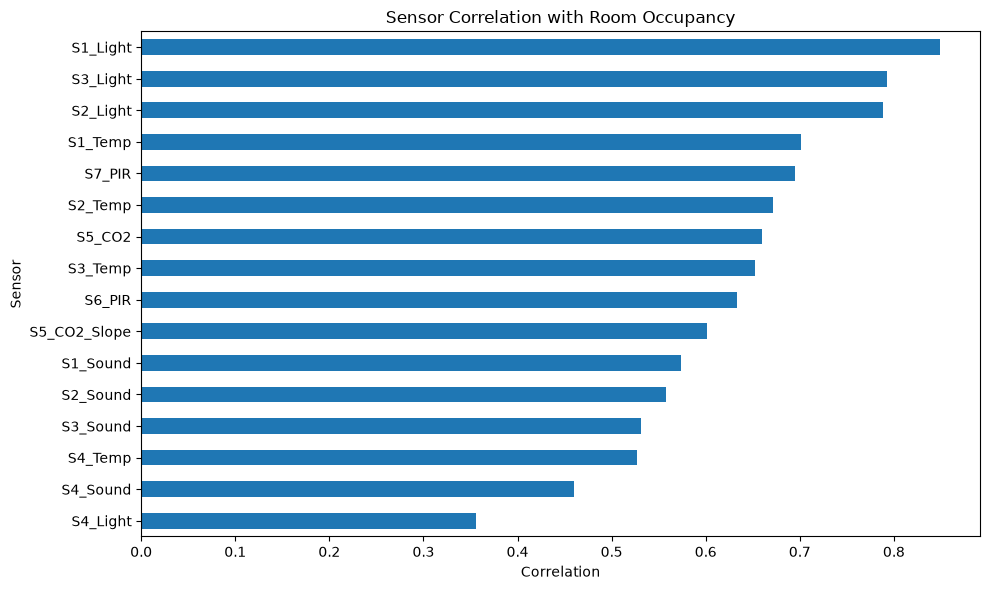

In [49]:
correlation_without_target = occupancy_correlation.drop(
    "Room_Occupancy_Count"
)

plt.figure(figsize=(10, 6))

correlation_without_target.sort_values().plot(
    kind="barh"
)

plt.title("Sensor Correlation with Room Occupancy")
plt.xlabel("Correlation")
plt.ylabel("Sensor")

plt.tight_layout()
plt.show()

In [50]:
correlation_matrix = df[
    sensor_columns + ["Room_Occupancy_Count"]
].corr()

correlation_matrix

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
S1_Temp,1.000000,0.799707,0.948839,0.855279,0.680743,0.548735,0.645163,0.212217,0.436099,0.391137,0.438769,0.355826,0.866718,0.137391,0.436363,0.474077,0.700868
S2_Temp,0.799707,1.000000,0.765525,0.696581,0.639773,0.645987,0.607349,0.370897,0.438274,0.409545,0.427133,0.378724,0.743722,0.202547,0.476901,0.465884,0.671263
S3_Temp,0.948839,0.765525,1.000000,0.885186,0.594311,0.500054,0.642601,0.301419,0.375183,0.344026,0.398177,0.326182,0.821308,0.095842,0.403355,0.460309,0.652047
S4_Temp,0.855279,0.696581,0.885186,1.000000,0.581482,0.456350,0.588459,0.386871,0.355111,0.312594,0.340808,0.294939,0.650320,0.106208,0.340000,0.339037,0.526509
S1_Light,0.680743,0.639773,0.594311,0.581482,1.000000,0.842090,0.816438,0.510853,0.601166,0.534274,0.494080,0.441712,0.602740,0.498185,0.607159,0.545213,0.849058
S2_Light,0.548735,0.645987,0.500054,0.456350,0.842090,1.000000,0.709579,0.458914,0.503021,0.560630,0.439269,0.413932,0.566764,0.493281,0.554658,0.556797,0.788764
S3_Light,0.645163,0.607349,0.642601,0.588459,0.816438,0.709579,1.000000,0.579484,0.502606,0.434859,0.577151,0.473606,0.650829,0.447708,0.501836,0.577815,0.793081
S4_Light,0.212217,0.370897,0.301419,0.386871,0.510853,0.458914,0.579484,1.000000,0.293632,0.303949,0.169702,0.200793,0.148608,0.212718,0.324545,0.220196,0.355715
S1_Sound,0.436099,0.438274,0.375183,0.355111,0.601166,0.503021,0.502606,0.293632,1.000000,0.560062,0.540736,0.557733,0.391903,0.335772,0.522015,0.463040,0.573748
S2_Sound,0.391137,0.409545,0.344026,0.312594,0.534274,0.560630,0.434859,0.303949,0.560062,1.000000,0.529830,0.578635,0.333836,0.357235,0.485697,0.507231,0.557853


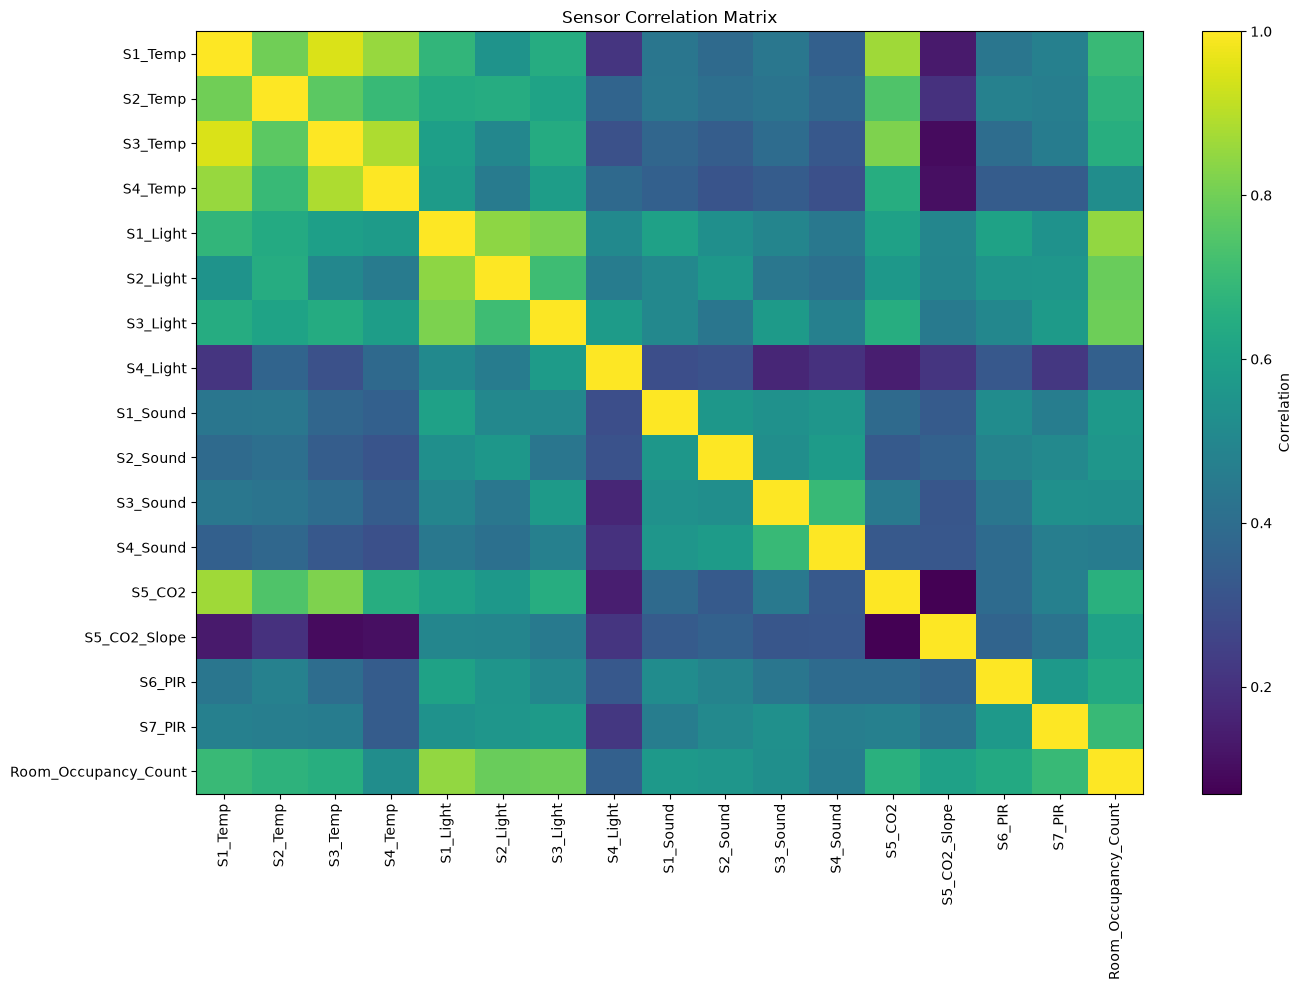

In [51]:
plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Sensor Correlation Matrix")

plt.tight_layout()
plt.show()

In [52]:
occupancy_sensor_profile = (
    df.groupby("Room_Occupancy_Count")[sensor_columns]
    .mean()
)

occupancy_sensor_profile



,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR
Room_Occupancy_Count,,,,,,,,,,,,,,,,
0,25.336365,25.371105,24.929206,25.659785,2.686558,3.053354,13.368498,9.234565,0.076895,0.052558,0.063765,0.079680,404.446403,-0.308078,0.002431,0.001458
1,25.741590,25.831285,25.297211,26.091002,120.209150,31.427015,54.230937,37.579521,0.444619,0.137320,0.129216,0.094858,470.718954,0.310625,0.344227,0.041394
2,26.003837,26.207233,25.594893,26.183168,136.109626,134.804813,138.339572,30.482620,0.642553,0.527767,0.646217,0.240013,713.168449,1.141881,0.478610,0.427807
3,26.066023,26.719035,25.827954,26.187378,113.317003,177.430836,156.393372,25.757925,0.556297,0.469597,0.769813,0.249452,851.239193,2.145877,0.543228,0.655620


In [53]:
co2_by_occupancy = (
    df.groupby("Room_Occupancy_Count")["S5_CO2"]
    .mean()
)

co2_by_occupancy

Room_Occupancy_Count
0    404.446403
1    470.718954
2    713.168449
3    851.239193
Name: S5_CO2, dtype: float64

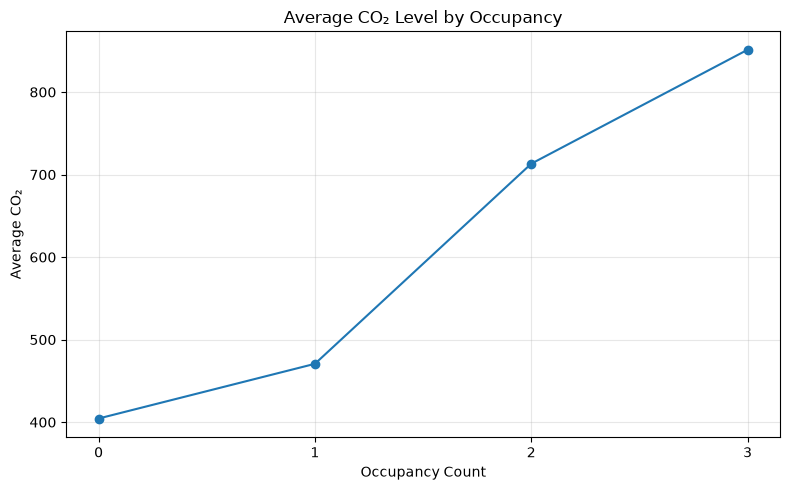

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    co2_by_occupancy.index,
    co2_by_occupancy.values,
    marker="o"
)

plt.title("Average CO₂ Level by Occupancy")
plt.xlabel("Occupancy Count")
plt.ylabel("Average CO₂")

plt.xticks(co2_by_occupancy.index)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
pir_by_occupancy = (
    df.groupby("Room_Occupancy_Count")[pir_columns]
    .mean()
)

pir_by_occupancy

,S6_PIR,S7_PIR
Room_Occupancy_Count,,
0,0.002431,0.001458
1,0.344227,0.041394
2,0.478610,0.427807
3,0.543228,0.655620


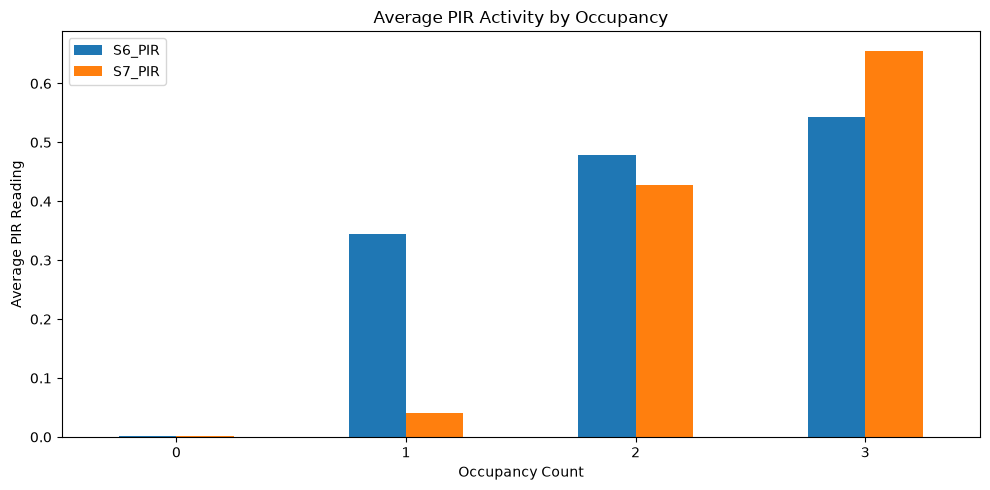

In [56]:
pir_by_occupancy.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average PIR Activity by Occupancy")
plt.xlabel("Occupancy Count")
plt.ylabel("Average PIR Reading")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [57]:
peak_occupancy = df["Room_Occupancy_Count"].max()

print("Peak Occupancy:", peak_occupancy)

Peak Occupancy: 3


In [58]:
peak_rows = df[
    df["Room_Occupancy_Count"] == peak_occupancy
]

print("Peak occupancy:", peak_occupancy)
print("First occurrence:", peak_rows["Timestamp"].min())
print("Last occurrence:", peak_rows["Timestamp"].max())

Peak occupancy: 3
First occurrence: 2017-12-22 12:30:16
Last occurrence: 2018-01-10 17:37:32


In [59]:
peak_hour = (
    df.groupby("Hour")["Room_Occupancy_Count"]
    .mean()
    .idxmax()
)

peak_hour_value = (
    df.groupby("Hour")["Room_Occupancy_Count"]
    .mean()
    .max()
)

print("Peak average occupancy hour:", peak_hour)
print("Average occupancy at that hour:", round(peak_hour_value, 2))

Peak average occupancy hour: 17
Average occupancy at that hour: 1.74


In [60]:
hourly_occupancy_sorted = hourly_occupancy.sort_values()

print("Lowest occupancy hours:")
print(hourly_occupancy_sorted.head())

Lowest occupancy hours:
Hour
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Room_Occupancy_Count, dtype: float64


In [61]:
max_capacity = df["Room_Occupancy_Count"].max()

df["Occupancy_Rate"] = (
    df["Room_Occupancy_Count"] / max_capacity
)

print("Maximum observed capacity:", max_capacity)
print("Average occupancy rate:",
      round(df["Occupancy_Rate"].mean() * 100, 2), "%")

Maximum observed capacity: 3
Average occupancy rate: 13.29 %


In [62]:
def classify_occupancy(occupancy):
    if occupancy == 0:
        return "Empty"
    elif occupancy < max_capacity:
        return "Partially Occupied"
    else:
        return "Fully Occupied"


df["Occupancy_Status"] = df["Room_Occupancy_Count"].apply(
    classify_occupancy
)

df[
    [
        "Timestamp",
        "Room_Occupancy_Count",
        "Occupancy_Rate",
        "Occupancy_Status"
    ]
].head()

,Timestamp,Room_Occupancy_Count,Occupancy_Rate,Occupancy_Status
0,2017-12-22 10:49:41,1,0.333333,Partially Occupied
1,2017-12-22 10:50:12,1,0.333333,Partially Occupied
2,2017-12-22 10:50:42,1,0.333333,Partially Occupied
3,2017-12-22 10:51:13,1,0.333333,Partially Occupied
4,2017-12-22 10:51:44,1,0.333333,Partially Occupied


In [63]:
occupancy_status_counts = (
    df["Occupancy_Status"]
    .value_counts()
)

occupancy_status_counts

Occupancy_Status
Empty                 8228
Partially Occupied    1207
Fully Occupied         694
Name: count, dtype: int64

In [64]:
occupancy_status_percentage = (
    df["Occupancy_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

occupancy_status_percentage

Occupancy_Status
Empty                 81.23
Partially Occupied    11.92
Fully Occupied         6.85
Name: proportion, dtype: float64

In [65]:
model_df = df.copy()

print("Modeling dataframe created.")
print("Shape:", model_df.shape)

Modeling dataframe created.
Shape: (10129, 26)


In [66]:
model_df[
    [
        "Timestamp",
        "Room_Occupancy_Count",
        "Hour",
        "Minute",
        "DayOfWeek"
    ]
].head()

,Timestamp,Room_Occupancy_Count,Hour,Minute,DayOfWeek
0,2017-12-22 10:49:41,1,10,49,4
1,2017-12-22 10:50:12,1,10,50,4
2,2017-12-22 10:50:42,1,10,50,4
3,2017-12-22 10:51:13,1,10,51,4
4,2017-12-22 10:51:44,1,10,51,4


In [67]:
target_distribution = (
    model_df["Room_Occupancy_Count"]
    .value_counts()
    .sort_index()
)

target_distribution

Room_Occupancy_Count
0    8228
1     459
2     748
3     694
Name: count, dtype: int64

In [68]:
model_df["Hour_sin"] = np.sin(
    2 * np.pi * model_df["Hour"] / 24
)

model_df["Hour_cos"] = np.cos(
    2 * np.pi * model_df["Hour"] / 24
)

model_df["Day_sin"] = np.sin(
    2 * np.pi * model_df["DayOfWeek"] / 7
)

model_df["Day_cos"] = np.cos(
    2 * np.pi * model_df["DayOfWeek"] / 7
)

model_df[
    [
        "Hour",
        "Hour_sin",
        "Hour_cos",
        "DayOfWeek",
        "Day_sin",
        "Day_cos"
    ]
].head()

,Hour,Hour_sin,Hour_cos,DayOfWeek,Day_sin,Day_cos
0,10,0.5,-0.866025,4,-0.433884,-0.900969
1,10,0.5,-0.866025,4,-0.433884,-0.900969
2,10,0.5,-0.866025,4,-0.433884,-0.900969
3,10,0.5,-0.866025,4,-0.433884,-0.900969
4,10,0.5,-0.866025,4,-0.433884,-0.900969


In [69]:
model_df["Occupancy_Lag_1"] = (
    model_df["Room_Occupancy_Count"].shift(1)
)

model_df["Occupancy_Lag_2"] = (
    model_df["Room_Occupancy_Count"].shift(2)
)

model_df["Occupancy_Lag_5"] = (
    model_df["Room_Occupancy_Count"].shift(5)
)

model_df["Occupancy_Lag_10"] = (
    model_df["Room_Occupancy_Count"].shift(10)
)

model_df[
    [
        "Timestamp",
        "Room_Occupancy_Count",
        "Occupancy_Lag_1",
        "Occupancy_Lag_2",
        "Occupancy_Lag_5",
        "Occupancy_Lag_10"
    ]
].head(15)

,Timestamp,Room_Occupancy_Count,Occupancy_Lag_1,Occupancy_Lag_2,Occupancy_Lag_5,Occupancy_Lag_10
0,2017-12-22 10:49:41,1,NaN,NaN,NaN,NaN
1,2017-12-22 10:50:12,1,1.0,NaN,NaN,NaN
2,2017-12-22 10:50:42,1,1.0,1.0,NaN,NaN
3,2017-12-22 10:51:13,1,1.0,1.0,NaN,NaN
4,2017-12-22 10:51:44,1,1.0,1.0,NaN,NaN
5,2017-12-22 10:52:14,1,1.0,1.0,1.0,NaN
6,2017-12-22 10:52:45,1,1.0,1.0,1.0,NaN
7,2017-12-22 10:53:15,1,1.0,1.0,1.0,NaN
8,2017-12-22 10:53:46,1,1.0,1.0,1.0,NaN
9,2017-12-22 10:54:17,1,1.0,1.0,1.0,NaN


In [70]:
model_df["Occupancy_Rolling_Mean_5"] = (
    model_df["Room_Occupancy_Count"]
    .shift(1)
    .rolling(window=5)
    .mean()
)

model_df["Occupancy_Rolling_Mean_10"] = (
    model_df["Room_Occupancy_Count"]
    .shift(1)
    .rolling(window=10)
    .mean()
)

model_df[
    [
        "Timestamp",
        "Room_Occupancy_Count",
        "Occupancy_Rolling_Mean_5",
        "Occupancy_Rolling_Mean_10"
    ]
].head(15)

,Timestamp,Room_Occupancy_Count,Occupancy_Rolling_Mean_5,Occupancy_Rolling_Mean_10
0,2017-12-22 10:49:41,1,NaN,NaN
1,2017-12-22 10:50:12,1,NaN,NaN
2,2017-12-22 10:50:42,1,NaN,NaN
3,2017-12-22 10:51:13,1,NaN,NaN
4,2017-12-22 10:51:44,1,NaN,NaN
5,2017-12-22 10:52:14,1,1.0,NaN
6,2017-12-22 10:52:45,1,1.0,NaN
7,2017-12-22 10:53:15,1,1.0,NaN
8,2017-12-22 10:53:46,1,1.0,NaN
9,2017-12-22 10:54:17,1,1.0,NaN


In [74]:
model_df["Target_Next_Occupancy"] = (
    model_df["Room_Occupancy_Count"].shift(-1)
)

model_df[
    [
        "Timestamp",
        "Room_Occupancy_Count",
        "Target_Next_Occupancy"
    ]
].head(10)

,Timestamp,Room_Occupancy_Count,Target_Next_Occupancy
0,2017-12-22 10:49:41,1,1.0
1,2017-12-22 10:50:12,1,1.0
2,2017-12-22 10:50:42,1,1.0
3,2017-12-22 10:51:13,1,1.0
4,2017-12-22 10:51:44,1,1.0
5,2017-12-22 10:52:14,1,1.0
6,2017-12-22 10:52:45,1,1.0
7,2017-12-22 10:53:15,1,1.0
8,2017-12-22 10:53:46,1,1.0
9,2017-12-22 10:54:17,1,1.0


In [75]:
model_df[
    [
        "Occupancy_Lag_1",
        "Occupancy_Lag_2",
        "Occupancy_Lag_5",
        "Occupancy_Lag_10",
        "Occupancy_Rolling_Mean_5",
        "Occupancy_Rolling_Mean_10",
        "Target_Next_Occupancy"
    ]
].isnull().sum()

Occupancy_Lag_1               1
Occupancy_Lag_2               2
Occupancy_Lag_5               5
Occupancy_Lag_10             10
Occupancy_Rolling_Mean_5      5
Occupancy_Rolling_Mean_10    10
Target_Next_Occupancy         1
dtype: int64

In [76]:
model_df = model_df.dropna().reset_index(drop=True)

print("Modeling data after removing incomplete rows:")
print("Shape:", model_df.shape)

Modeling data after removing incomplete rows:
Shape: (10118, 37)


In [77]:
print("Remaining missing values:",
      model_df.isnull().sum().sum())

print("Remaining duplicate rows:",
      model_df.duplicated().sum())

Remaining missing values: 0
Remaining duplicate rows: 0


In [78]:
model_df[
    [
        "Timestamp",
        "Room_Occupancy_Count",
        "Occupancy_Lag_1",
        "Occupancy_Lag_5",
        "Occupancy_Rolling_Mean_5",
        "Hour_sin",
        "Hour_cos",
        "Target_Next_Occupancy"
    ]
].head(10)

,Timestamp,Room_Occupancy_Count,Occupancy_Lag_1,Occupancy_Lag_5,Occupancy_Rolling_Mean_5,Hour_sin,Hour_cos,Target_Next_Occupancy
0,2017-12-22 10:54:47,1,1.0,1.0,1.0,0.5,-0.866025,1.0
1,2017-12-22 10:55:18,1,1.0,1.0,1.0,0.5,-0.866025,1.0
2,2017-12-22 10:55:49,1,1.0,1.0,1.0,0.5,-0.866025,1.0
3,2017-12-22 10:56:19,1,1.0,1.0,1.0,0.5,-0.866025,1.0
4,2017-12-22 10:56:50,1,1.0,1.0,1.0,0.5,-0.866025,1.0
5,2017-12-22 10:57:21,1,1.0,1.0,1.0,0.5,-0.866025,1.0
6,2017-12-22 10:57:51,1,1.0,1.0,1.0,0.5,-0.866025,1.0
7,2017-12-22 10:58:22,1,1.0,1.0,1.0,0.5,-0.866025,1.0
8,2017-12-22 10:58:52,1,1.0,1.0,1.0,0.5,-0.866025,1.0
9,2017-12-22 10:59:23,1,1.0,1.0,1.0,0.5,-0.866025,1.0


In [79]:
forecast_features = [
    "Hour",
    "Minute",
    "DayOfWeek",
    "Hour_sin",
    "Hour_cos",
    "Day_sin",
    "Day_cos",
    "Occupancy_Lag_1",
    "Occupancy_Lag_2",
    "Occupancy_Lag_5",
    "Occupancy_Lag_10",
    "Occupancy_Rolling_Mean_5",
    "Occupancy_Rolling_Mean_10"
]

# Add sensor features
forecast_features.extend(sensor_columns)

target_column = "Target_Next_Occupancy"

print("Number of forecasting features:", len(forecast_features))
print("\nTarget:", target_column)

Number of forecasting features: 29

Target: Target_Next_Occupancy


In [80]:
missing_features = [
    col for col in forecast_features
    if col not in model_df.columns
]

print("Missing forecasting features:", missing_features)

if not missing_features:
    print("All forecasting features are available.")

Missing forecasting features: []
All forecasting features are available.


In [81]:
X = model_df[forecast_features]
y = model_df[target_column]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (10118, 29)
Target shape: (10118,)


In [82]:
print("Target statistics:")
print(y.describe())

print("\nTarget values:")
print(sorted(y.unique()))

Target statistics:
count    10118.000000
mean         0.397905
std          0.893899
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Target_Next_Occupancy, dtype: float64

Target values:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


In [83]:
split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8094
Testing samples: 2024


In [84]:
print("Training period:")
print(X_train.index.min(), "→", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "→", X_test.index.max())

Training period:
0 → 8093

Testing period:
8094 → 10117


In [85]:
print("\nActual training timestamps:")
print(model_df["Timestamp"].iloc[:split_index].min())
print("→", model_df["Timestamp"].iloc[:split_index].max())

print("\nActual testing timestamps:")
print(model_df["Timestamp"].iloc[split_index:].min())
print("→", model_df["Timestamp"].iloc[split_index:].max())


Actual training timestamps:
2017-12-22 10:54:47
→ 2018-01-10 15:35:30

Actual testing timestamps:
2018-01-10 15:36:01
→ 2018-01-11 08:59:39


In [86]:
baseline_predictions = (
    model_df["Room_Occupancy_Count"]
    .iloc[split_index:]
    .values
)

print("Baseline predictions generated.")
print("Number of predictions:", len(baseline_predictions))

Baseline predictions generated.
Number of predictions: 2024


In [87]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

print("Evaluation metrics imported.")

Evaluation metrics imported.


In [88]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print("Baseline MAE:", round(baseline_mae, 4))
print("Baseline RMSE:", round(baseline_rmse, 4))

Baseline MAE: 0.0025
Baseline RMSE: 0.0588


In [89]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest imported.")

Random Forest imported.


In [90]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [91]:
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [92]:
rf_predictions = rf_model.predict(X_test)

print("Predictions generated.")
print("Number of predictions:", len(rf_predictions))

Predictions generated.
Number of predictions: 2024


In [93]:
rf_predictions_rounded = np.rint(
    rf_predictions
).astype(int)

rf_predictions_rounded = np.clip(
    rf_predictions_rounded,
    0,
    int(max_capacity)
)

print("Sample predictions:")
print(rf_predictions_rounded[:20])

Sample predictions:
[3 3 3 2 3 3 2 3 3 3 3 2 2 3 3 3 3 3 3 3]


In [94]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions_rounded
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions_rounded
    )
)

print("Random Forest MAE:", round(rf_mae, 4))
print("Random Forest RMSE:", round(rf_rmse, 4))

Random Forest MAE: 0.0425
Random Forest RMSE: 0.2085


In [95]:
exact_accuracy = (
    np.mean(
        rf_predictions_rounded == y_test.values
    ) * 100
)

print(
    f"Exact occupancy forecasting accuracy: "
    f"{exact_accuracy:.2f}%"
)

Exact occupancy forecasting accuracy: 95.80%


In [96]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,Naive Baseline,0.00247,0.058809
1,Random Forest,0.04249,0.208514


In [97]:
print("Forecasting Performance")
print("=" * 40)

print(f"Baseline MAE:       {baseline_mae:.4f}")
print(f"Baseline RMSE:      {baseline_rmse:.4f}")

print()

print(f"Random Forest MAE:  {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")

print()

print(
    f"Exact Accuracy:     {exact_accuracy:.2f}%"
)

if exact_accuracy >= 80:
    print("Requirement status: PASSED")
else:
    print("Requirement status: NOT YET PASSED")

Forecasting Performance
Baseline MAE:       0.0025
Baseline RMSE:      0.0588

Random Forest MAE:  0.0425
Random Forest RMSE: 0.2085

Exact Accuracy:     95.80%
Requirement status: PASSED


In [98]:
prediction_df = pd.DataFrame({
    "Timestamp": model_df["Timestamp"].iloc[split_index:].values,
    "Actual_Occupancy": y_test.values,
    "Predicted_Occupancy": rf_predictions_rounded
})

prediction_df.head(10)

,Timestamp,Actual_Occupancy,Predicted_Occupancy
0,2018-01-10 15:36:01,3.0,3
1,2018-01-10 15:36:31,3.0,3
2,2018-01-10 15:37:02,3.0,3
3,2018-01-10 15:37:33,3.0,2
4,2018-01-10 15:38:03,3.0,3
5,2018-01-10 15:38:34,3.0,3
6,2018-01-10 15:39:04,3.0,2
7,2018-01-10 15:39:35,3.0,3
8,2018-01-10 15:40:06,3.0,3
9,2018-01-10 15:40:36,3.0,3


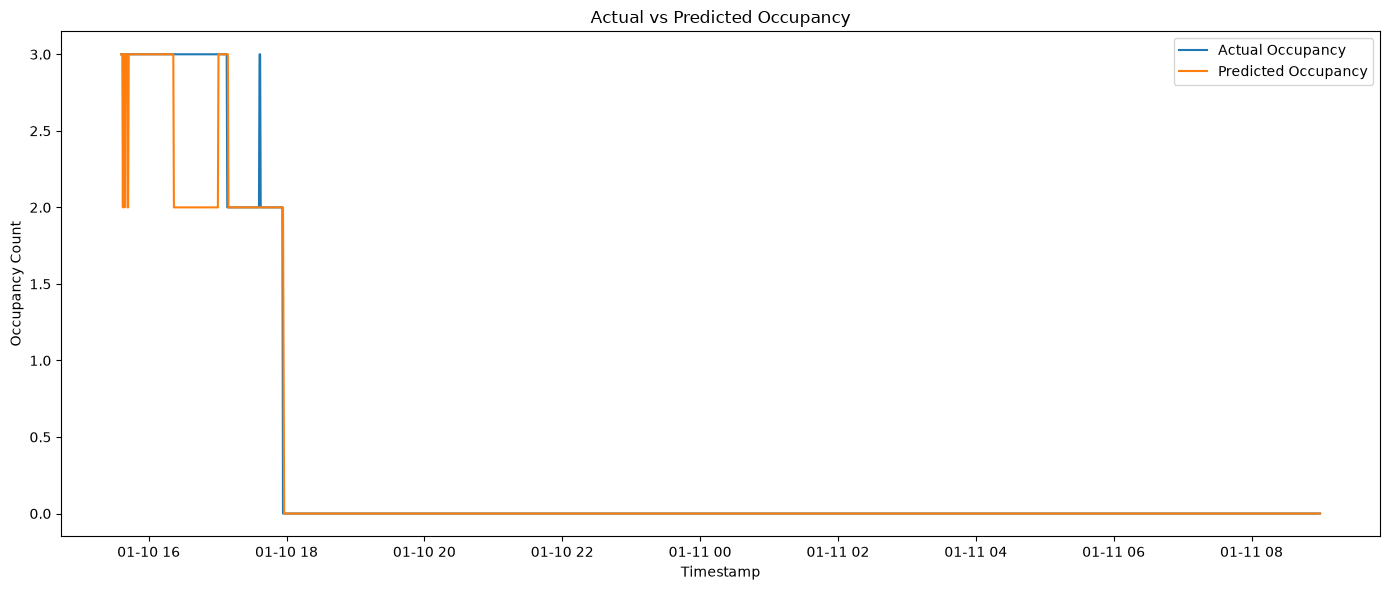

In [99]:
plt.figure(figsize=(14, 6))

plt.plot(
    prediction_df["Timestamp"],
    prediction_df["Actual_Occupancy"],
    label="Actual Occupancy"
)

plt.plot(
    prediction_df["Timestamp"],
    prediction_df["Predicted_Occupancy"],
    label="Predicted Occupancy"
)

plt.title("Actual vs Predicted Occupancy")
plt.xlabel("Timestamp")
plt.ylabel("Occupancy Count")
plt.legend()

plt.tight_layout()
plt.show()

In [100]:
feature_importance = pd.DataFrame({
    "Feature": forecast_features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,Occupancy_Lag_1,0.916434
17,S1_Light,0.071556
19,S3_Light,0.001514
23,S3_Sound,0.001427
22,S2_Sound,0.001335
18,S2_Light,0.001332
11,Occupancy_Rolling_Mean_5,0.000910
26,S5_CO2_Slope,0.000847
20,S4_Light,0.000796
24,S4_Sound,0.000707


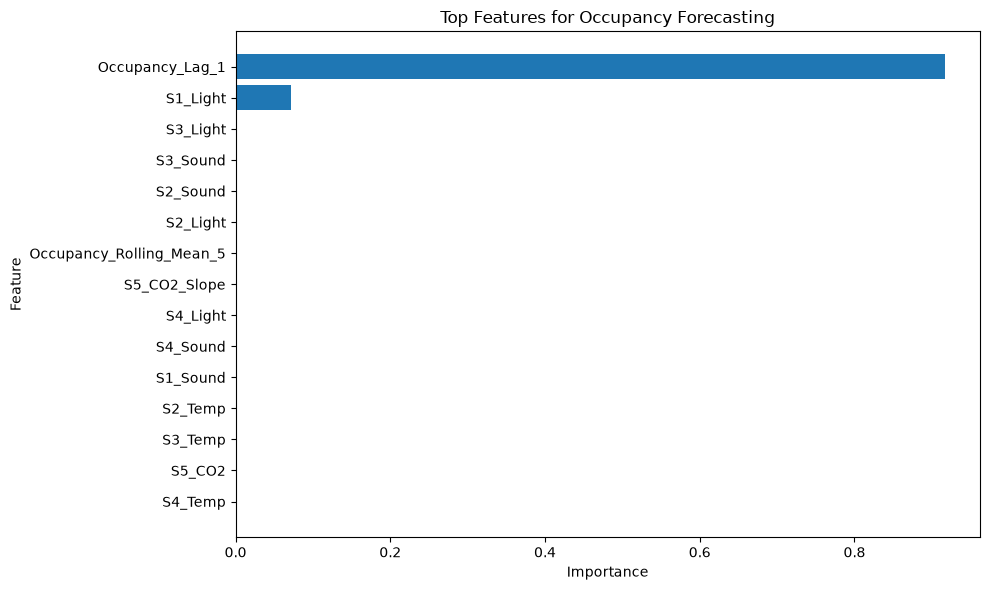

In [101]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features for Occupancy Forecasting")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [102]:
baseline_exact_accuracy = np.mean(
    baseline_predictions == y_test.values
) * 100

print(f"Naive Baseline Exact Accuracy: {baseline_exact_accuracy:.2f}%")

Naive Baseline Exact Accuracy: 99.80%


In [103]:
from sklearn.metrics import classification_report

y_test_int = y_test.astype(int)
rf_predictions_int = rf_predictions_rounded.astype(int)

print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test_int,
        rf_predictions_int,
        zero_division=0
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1751
           1       0.00      0.00      0.00         0
           2       0.53      0.98      0.68        93
           3       0.98      0.55      0.70       180

    accuracy                           0.96      2024
   macro avg       0.63      0.63      0.60      2024
weighted avg       0.98      0.96      0.96      2024



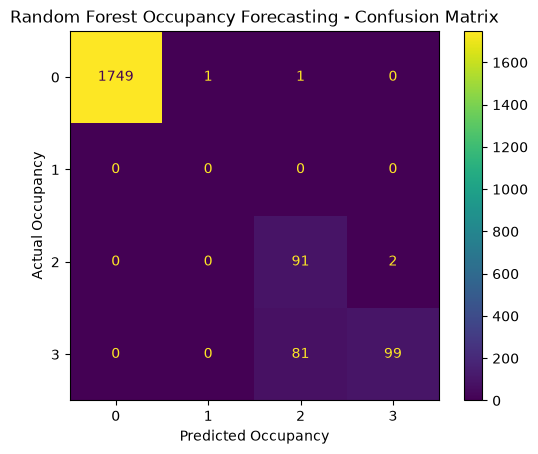

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Occupancy classes in the original dataset
occupancy_classes = [0, 1, 2, 3]

cm = confusion_matrix(
    y_test_int,
    rf_predictions_int,
    labels=occupancy_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=occupancy_classes
)

disp.plot()

plt.title("Random Forest Occupancy Forecasting - Confusion Matrix")
plt.xlabel("Predicted Occupancy")
plt.ylabel("Actual Occupancy")
plt.show()

In [106]:
current_test_occupancy = (
    model_df["Room_Occupancy_Count"]
    .iloc[split_index:]
    .values
    .astype(int)
)

actual_next_occupancy = y_test.values.astype(int)

transition_mask = (
    current_test_occupancy != actual_next_occupancy
)

print(
    f"Total test samples: {len(actual_next_occupancy)}"
)

print(
    f"Occupancy transition samples: "
    f"{transition_mask.sum()}"
)

Total test samples: 2024
Occupancy transition samples: 4


In [107]:
if transition_mask.sum() > 0:

    transition_accuracy = np.mean(
        rf_predictions_int[transition_mask]
        == actual_next_occupancy[transition_mask]
    ) * 100

    print(
        f"Random Forest Accuracy on Occupancy Changes: "
        f"{transition_accuracy:.2f}%"
    )

else:
    print("No occupancy transitions found in the test set.")

Random Forest Accuracy on Occupancy Changes: 25.00%


In [108]:
# Analyze actual occupancy transitions

current_test_occupancy = (
    model_df["Room_Occupancy_Count"]
    .iloc[split_index:]
    .values
    .astype(int)
)

actual_next_occupancy = y_test.values.astype(int)

transition_mask = (
    current_test_occupancy != actual_next_occupancy
)

transition_df = pd.DataFrame({
    "Current_Occupancy": current_test_occupancy[transition_mask],
    "Actual_Next_Occupancy": actual_next_occupancy[transition_mask],
    "RF_Predicted_Occupancy": rf_predictions_int[transition_mask]
})

print(f"Total test samples: {len(actual_next_occupancy)}")
print(f"Actual occupancy transitions: {transition_mask.sum()}")

transition_df

Total test samples: 2024
Actual occupancy transitions: 4


,Current_Occupancy,Actual_Next_Occupancy,RF_Predicted_Occupancy
0,3,2,3
1,2,3,2
2,3,2,2
3,2,0,2


In [109]:
# Evaluate Random Forest specifically on occupancy transitions

if len(transition_df) > 0:

    transition_accuracy = (
        np.mean(
            transition_df["RF_Predicted_Occupancy"]
            == transition_df["Actual_Next_Occupancy"]
        ) * 100
    )

    print(
        f"Random Forest Accuracy on Occupancy Changes: "
        f"{transition_accuracy:.2f}%"
    )

else:
    print("No occupancy transitions found.")

Random Forest Accuracy on Occupancy Changes: 25.00%


In [110]:
## Save models 
import os
import joblib
import json

# Create models directory if it doesn't exist
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# Save trained Random Forest model
model_path = os.path.join(
    models_dir,
    "occupancy_random_forest.joblib"
)

joblib.dump(rf_model, model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: ../models\occupancy_random_forest.joblib


In [111]:
# Save the exact feature columns used by the model

feature_info = {
    "features": list(X_train.columns),
    "target": "Target_Next_Occupancy",
    "model": "RandomForestRegressor",
    "prediction_type": "Next-step occupancy forecasting",
    "forecast_horizon": "30 seconds"
}

feature_info_path = os.path.join(
    models_dir,
    "occupancy_model_features.json"
)

with open(feature_info_path, "w") as f:
    json.dump(feature_info, f, indent=4)

print(f"Feature information saved at: {feature_info_path}")

Feature information saved at: ../models\occupancy_model_features.json


In [112]:
import joblib
import os

# Load the saved model
saved_model_path = "../models/occupancy_random_forest.joblib"

loaded_model = joblib.load(saved_model_path)

print("Model loaded successfully.")
print("Model type:", type(loaded_model).__name__)

Model loaded successfully.
Model type: RandomForestRegressor


In [113]:
# Verify the loaded model can make predictions

sample_predictions = loaded_model.predict(
    X_test.head(5)
)

sample_predictions = np.rint(
    sample_predictions
).astype(int)

print("Sample predictions from loaded model:")
print(sample_predictions)

print("\nActual occupancy:")
print(y_test.head(5).astype(int).values)

Sample predictions from loaded model:
[3 3 3 2 3]

Actual occupancy:
[3 3 3 3 3]


In [114]:
# Test occupancy_forecasting.py
import sys
import os

# Add occupancy_system/src to Python path
src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)

from occupancy_forecasting import (
    load_model,
    load_feature_info,
    forecast_with_details
)

print("Occupancy forecasting module imported successfully.")

Occupancy forecasting module imported successfully.


In [115]:
# Verify model loading through the production module

model = load_model()
feature_info = load_feature_info()

print("Model loaded:", type(model).__name__)
print("Number of model features:", len(feature_info["features"]))
print("Target:", feature_info["target"])
print("Forecast horizon:", feature_info["forecast_horizon"])

Model loaded: RandomForestRegressor
Number of model features: 29
Target: Target_Next_Occupancy
Forecast horizon: 30 seconds


In [116]:
# Test an actual next-step occupancy forecast

forecast_result = forecast_with_details(df)

print("Occupancy Forecast Result:")
print(forecast_result)

Occupancy Forecast Result:
{'timestamp': '2018-01-11 09:00:09', 'current_occupancy': 0, 'predicted_next_occupancy': 0, 'forecast_horizon': '30 seconds'}


In [117]:
## Test occupancy_agent.py 
# test occupancy_agent.py import

from occupancy_agent import OccupancyAgent

# Create the agent
occupancy_agent = OccupancyAgent()

print("Occupancy Agent initialized successfully.")
print("Agent name:", occupancy_agent.agent_name)


Occupancy Agent initialized successfully.
Agent name: Occupancy Agent


In [118]:
# Test current occupancy intelligence

current_occupancy = occupancy_agent.get_current_occupancy(df)

status = occupancy_agent.get_occupancy_status(
    current_occupancy
)

print("Current Occupancy:", current_occupancy)
print("Occupancy Status:", status)

Current Occupancy: 0
Occupancy Status: VACANT


In [119]:
# Test occupancy KPIs

occupancy_rate = occupancy_agent.calculate_occupancy_rate(df)

average_occupancy = occupancy_agent.calculate_average_occupancy(df)

maximum_occupancy = occupancy_agent.calculate_max_occupancy(df)

print(f"Occupancy Rate: {occupancy_rate:.2f}%")
print(f"Average Occupancy: {average_occupancy:.2f}")
print(f"Maximum Occupancy: {maximum_occupancy}")

Occupancy Rate: 18.77%
Average Occupancy: 0.40
Maximum Occupancy: 3


In [120]:
# Run complete Occupancy Agent analysis

occupancy_result = occupancy_agent.analyze(df)

print("=== OCCUPANCY AGENT RESULT ===")

for key, value in occupancy_result.items():
    print(f"{key}: {value}")

=== OCCUPANCY AGENT RESULT ===
agent: Occupancy Agent
current_occupancy: 0
current_status: VACANT
occupancy_rate_percent: 18.77
average_occupancy: 0.4
maximum_occupancy: 3
forecast: {'timestamp': '2018-01-11 09:00:09', 'current_occupancy': 0, 'predicted_next_occupancy': 0, 'forecast_horizon': '30 seconds'}
